In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from Src.data_modules import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,cohen_kappa_score, make_scorer, mean_squared_error, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.utils import shuffle

import xgboost as xgb
from tqdm import tqdm

from sklearn.svm import SVC

# Data loading

In [33]:
data_model = pd.read_csv("data_model.csv", sep=";", index_col=0)

y = data_model["target"]
X = data_model.drop(columns=["target"])

In [56]:
test_data_model = pd.read_csv("test_data_model.csv", sep=";", index_col=0)

# X_test = data_model.drop(columns=["target"])

In [3]:
data_model

,mode_0,mode_1,mode_2,mode_3,amplitude,target
0,2.108017,3.766613,0.000000,2.584784,20056.871,0
1,5.632278,5.586515,0.702054,2.434528,18176.380,0
2,1.129253,4.057986,0.000000,1.383936,18218.500,0
3,1.247747,3.728297,0.009119,2.008376,18827.771,0
4,2.367924,3.358915,0.000000,1.701230,19442.460,0
...,...,...,...,...,...,...
261750,14.223799,6.338595,1.862412,1.812356,71428.766,0
261751,24.995213,14.817390,0.599471,2.269399,79437.570,0
261752,10.944218,6.434064,3.183469,2.152396,88409.680,0
261753,11.556972,6.026230,2.642583,1.532516,88166.570,0


In [5]:
test_data_model

,mode_0,mode_1,mode_2,mode_3,amplitude
0,21.219572,9.470988,7.524747,1.455186,1.541605e+06
1,17.731410,8.321794,9.744177,1.414656,2.239955e+06
2,12.736122,7.476161,3.518530,1.574906,2.188355e+06
3,13.011054,4.569553,2.304483,0.869931,2.182809e+06
4,11.482360,7.111195,2.449824,0.011326,2.186340e+06
...,...,...,...,...,...
112610,7.261078,3.395464,1.797075,0.280240,2.140521e+03
112611,14.427754,6.376949,6.853260,1.828387,3.069335e+03
112612,23.947513,11.630581,5.590073,0.000000,-6.372085e+03
112613,6.617773,3.476538,3.829220,1.788417,-7.140743e+03


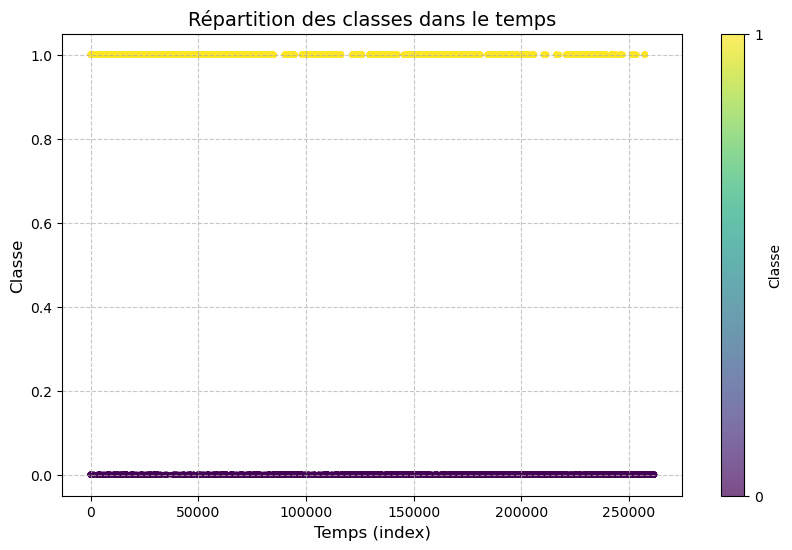

In [21]:
# Création d'un DataFrame
data = pd.DataFrame({
    'timestamp': np.arange(data_model.shape[0]),
    'class': y
})

# Visualisation de la répartition des classes dans le temps
plt.figure(figsize=(10, 6))
plt.scatter(data['timestamp'], data['class'], c=data['class'], cmap='viridis', alpha=0.7, s=10)
plt.title('Répartition des classes dans le temps', fontsize=14)
plt.xlabel('Temps (index)', fontsize=12)
plt.ylabel('Classe', fontsize=12)
plt.colorbar(label='Classe', ticks=[0, 1])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Training data

In [34]:
# Normaliser les données d'entrée
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

## Test data

In [57]:
# Normaliser les données d'entrée
scaler = StandardScaler()
test_data_model = scaler.fit_transform(test_data_model)

In [53]:
# Mélanger les données X et les labels y
X, y = shuffle(X, y, random_state=42)

# Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [6]:
# # Diviser les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Créer et entraîner le modèle de régression logistique
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Prédire les résultats sur les données de test
y_pred = model.predict(X_test)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitude du modèle : {accuracy:.2f}")

# Afficher un rapport détaillé sur les performances
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

Exactitude du modèle : 0.92
Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     31485
           1       0.93      0.94      0.94     47042

    accuracy                           0.92     78527
   macro avg       0.92      0.92      0.92     78527
weighted avg       0.92      0.92      0.92     78527

Score Kappa : 0.8410735268037804


In [7]:
# Prédire les résultats sur les données de test
y_pred = model.predict(X_train)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_train, y_pred)
print(f"Exactitude du modèle : {accuracy:.2f}")

# Afficher un rapport détaillé sur les performances
print("Rapport de classification :")
print(classification_report(y_train, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_train, y_pred)

print(f"Score Kappa : {kappa_score}")

Exactitude du modèle : 0.92
Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     73809
           1       0.93      0.94      0.94    109419

    accuracy                           0.92    183228
   macro avg       0.92      0.92      0.92    183228
weighted avg       0.92      0.92      0.92    183228

Score Kappa : 0.8405927135513747


In [83]:
# Liste des valeurs de C à tester
C_values = np.logspace(-4, 4, 20)  # Exemple : valeurs entre 10^-4 et 10^4

# Variable pour stocker le meilleur score et la meilleure valeur de C
best_C = None
best_mse = float('inf')

# Boucle pour tester les différentes valeurs de C
for C in C_values:
    # Créer et entraîner le modèle
    model = LogisticRegression(C=C, penalty='l2', solver='lbfgs')
    model.fit(X_train, y_train)

    # Prédictions sur l'ensemble de validation
    y_pred = model.predict(X_test)

    # Calcul du MSE (Mean Squared Error)
    mse = accuracy_score(y_test, y_pred)

    # Vérifier si ce MSE est le plus bas
    if mse < best_mse:
        best_mse = mse
        best_C = C

# Affichage du meilleur paramètre C et du MSE correspondant
print(f"Meilleur C : {best_C}")
print(f"MSE correspondant : {best_mse}")

Meilleur C : 4.281332398719396
MSE correspondant : 0.8467024080889376


# Random Forest

In [54]:
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=20, min_samples_leaf=1, min_samples_split=2)  # 100 arbres dans la forêt
model.fit(X, y)

RandomForestClassifier(max_depth=20, random_state=42)

In [37]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=20, min_samples_leaf=1, min_samples_split=5)  # 100 arbres dans la forêt
rf_clf.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = rf_clf.predict(X_test)

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

Accuracy: 0.8539610579800578

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89     54590
           1       0.74      0.81      0.77     23937

    accuracy                           0.85     78527
   macro avg       0.82      0.84      0.83     78527
weighted avg       0.86      0.85      0.86     78527

Score Kappa : 0.6646829482959804


In [31]:
# Prédire les résultats sur les données de test
y_pred = rf_clf.predict(X_train)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_train, y_pred)
print(f"Exactitude du modèle : {accuracy:.2f}")

# Afficher un rapport détaillé sur les performances
print("Rapport de classification :")
print(classification_report(y_train, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_train, y_pred)

print(f"Score Kappa : {kappa_score}")

Exactitude du modèle : 0.96
Rapport de classification :
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     50704
           1       0.97      0.98      0.97    132524

    accuracy                           0.96    183228
   macro avg       0.96      0.95      0.95    183228
weighted avg       0.96      0.96      0.96    183228

Score Kappa : 0.9062005269296749


In [36]:
# Hyperparamètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Créer la grille
grid = ParameterGrid(param_grid)

best_score = -1
best_params = None

# Parcourir les combinaisons d'hyperparamètres avec tqdm
for params in tqdm(grid, desc="Recherche d'hyperparamètres"):
    # Initialiser le modèle avec les hyperparamètres actuels
    model = RandomForestClassifier(**params, random_state=42)
    
    # Entraîner le modèle
    model.fit(X_train, y_train)
    
    # Prédire sur les données de validation
    y_pred = model.predict(X_test)
    
    # Calculer le F1-score
    f1 = f1_score(y_test, y_pred, average='weighted')  # Utilise 'weighted' pour les classes déséquilibrées
    
    # Vérifier si ce score est le meilleur
    if f1 > best_score:
        best_score = f1
        best_params = params

# Afficher les résultats
print("Meilleurs hyperparamètres :", best_params)
print("Meilleur F1-score :", best_score)

Recherche d'hyperparamètres: 100%|██████████| 16/16 [08:56<00:00, 33.52s/it]

Meilleurs hyperparamètres : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur F1-score : 0.8557755386452931


# XGBoost

In [8]:
# Créer un modèle XGBoost
model = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

# Faire des prédictions
y_pred = model.predict(X_test)

# Calculer l'accuracy (précision)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

Accuracy: 0.9527

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94     31485
           1       0.96      0.96      0.96     47042

    accuracy                           0.95     78527
   macro avg       0.95      0.95      0.95     78527
weighted avg       0.95      0.95      0.95     78527

Score Kappa : 0.9012223296542297


In [9]:
# Prédire les résultats sur les données de test
y_pred = model.predict(X_train)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_train, y_pred)
print(f"Exactitude du modèle : {accuracy:.2f}")

# Afficher un rapport détaillé sur les performances
print("Rapport de classification :")
print(classification_report(y_train, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_train, y_pred)

print(f"Score Kappa : {kappa_score}")

Exactitude du modèle : 0.96
Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     73809
           1       0.96      0.97      0.97    109419

    accuracy                           0.96    183228
   macro avg       0.96      0.96      0.96    183228
weighted avg       0.96      0.96      0.96    183228

Score Kappa : 0.9211558780425602


In [11]:
# Modèle XGBoost
model = xgb.XGBClassifier(random_state=42)

# Paramètres à tester dans GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Créer un scorer basé sur le Cohen Kappa
kappa_scorer = make_scorer(cohen_kappa_score)

# Créer un objet GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring=kappa_scorer, cv=5, verbose=0)

# Liste de toutes les combinaisons de paramètres
param_combinations = list(ParameterGrid(param_grid))

# Utiliser tqdm pour suivre la progression des itérations
with tqdm(total=len(param_combinations), desc="Entraînement GridSearch", ncols=100) as pbar:
    best_score = -1
    best_params = None
    for params in param_combinations:
        model.set_params(**params)
        model.fit(X_train, y_train)
        score = cohen_kappa_score(y_test, model.predict(X_test))
        
        if score > best_score:
            best_score = score
            best_params = params

        pbar.update(1)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", best_params)

# Prédictions avec le meilleur modèle
best_model = xgb.XGBClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Calculer le score Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Score Kappa avec les meilleurs paramètres : {kappa_score:.4f}")

Entraînement GridSearch: 100%|████████████████████████████████████| 243/243 [01:23<00:00,  2.90it/s]


Meilleurs hyperparamètres : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Score Kappa avec les meilleurs paramètres : 0.9050


In [27]:
model = xgb.XGBClassifier(random_state=42, colsample_bytree= 0.8, learning_rate=0.2, max_depth=7, n_estimators=100, subsample=0.8)
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [14]:
y_pred = best_model.predict(X_test)

# Calculer le score Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Score Kappa avec les meilleurs paramètres : {kappa_score:.4f}")

Score Kappa avec les meilleurs paramètres : 0.9050


# SVM

In [ ]:
# Création du modèle SVM
# Utilisez un noyau linéaire ou RBF (Radial Basis Function)
svm = SVC(kernel='linear', C=1.0)  # 'linear' pour un noyau linéaire, 'rbf' pour un noyau RBF

# Entraînement du modèle
svm.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = svm.predict(X_test)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitude du modèle : {accuracy:.2f}")

# Afficher un rapport détaillé sur les performances
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

# Submission

In [58]:
def format_array_to_target_format(array, record_number, nb_points):

    formatted_target = []
    for i in range(5):
        channel_encoding = (i + 1) * 100000
        record_number_encoding = record_number * 1000000
        for j in range(nb_points):
            formatted_target.append(
                {
                    "identifier": record_number_encoding + channel_encoding + j,
                    "target": array[i][j],
                }
            )
    return formatted_target

In [59]:
results = []

# Set 4
X_test_4 = test_data_model[:66020]
preds = model.predict(X_test_4)
sublists = [preds[i:i + 13204] for i in range(0, len(preds), 13204)]

formatted_preds = format_array_to_target_format(sublists, 4, 13204)
results.extend(formatted_preds)

# Set 5
X_test_5 = test_data_model[66020:]
preds = model.predict(X_test_5)
sublists = [preds[i:i + 9319] for i in range(0, len(preds), 9319)]

formatted_preds = format_array_to_target_format(sublists, 5, 9319)
results.extend(formatted_preds)

df = pd.DataFrame(results)
df.to_csv("../Results/my_submission_rf_scaled.csv",index = False)